# 07 — Who declines the income question, across cohorts and years?

Notebook 02 showed a striking split: **refusing** the income question and saying
**don't know** trace different demographic patterns, especially by education. Here we
follow that thread across **eight BRFSS survey years (2011–2023)** to ask:

1. **Has the pattern stayed the same over time?** — trends in refusal and don't-know
   rates, overall and by education.
2. **Does it differ by birth cohort?** — refusal/don't-know by age group within each
   year (the age × period × cohort view).

We keep **Refused (99)** and **Don't know (77)** distinct throughout, and condition on
respondents who were *asked* the income item (so we measure response behavior, not the
questionnaire-skip pattern). One caveat to watch: the income item changed from
`INCOME2` (8 brackets, through 2020) to `INCOME3` (11 brackets, 2021+) — an
instrument change that could itself move nonresponse, marked on the year plots.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import multiyear as my

DATA = os.path.abspath(os.path.join('..', 'data'))
RAW = os.path.join(DATA, 'raw', 'brfss')
DERIVED = os.path.join(DATA, 'derived')

df = my.load_all(RAW)                  # extracts per-year XPTs as needed (cached)
df = df[df['income_asked']].copy()     # condition on being asked the income item
print('pooled respondents (asked income):', len(df))
# verify the income variable used per year and the raw refusal/DK rates
chk = df.groupby('year').agg(income_var=('income_var', 'first'),
                             n=('w', 'size'),
                             refused_pct=('refused', lambda s: round(100*s.mean(), 2)),
                             dk_pct=('dk', lambda s: round(100*s.mean(), 2)))
print(chk.to_string())

pooled respondents (asked income): 3579876


     income_var       n  refused_pct  dk_pct
year                                        
2011    INCOME2  505468         7.20    7.16
2013    INCOME2  490887         7.24    7.12
2015    INCOME2  438155         9.35    8.05
2017    INCOME2  446685         8.60    7.46
2019    INCOME2  411387         9.78    7.94
2021    INCOME3  429846        11.50    8.41
2022    INCOME3  432200        10.87    8.36
2023    INCOME3  425248         9.93    8.54


## 1. Trends over survey years

Survey-weighted share refusing vs saying don't know, by year. The dashed line marks
the 2021 `INCOME2`→`INCOME3` instrument change.

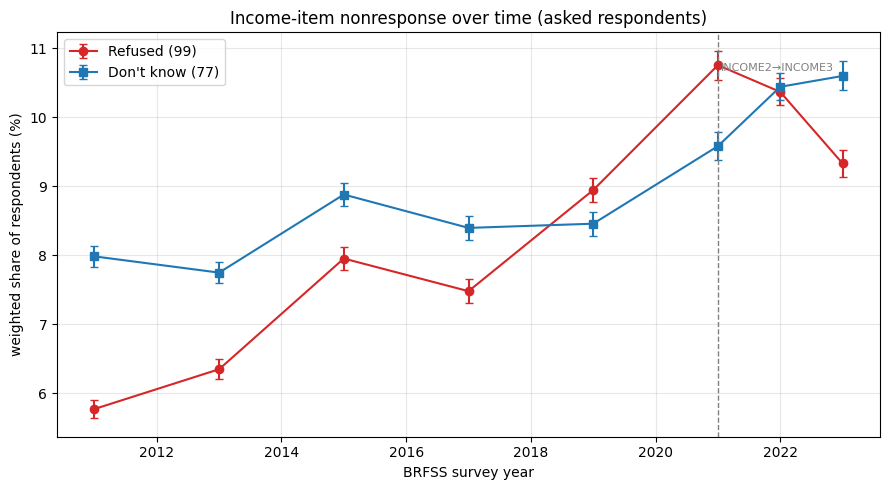

In [2]:
ref_y = my.wprop(df, 'refused', by='year')
dk_y = my.wprop(df, 'dk', by='year')
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(ref_y['year'], 100*ref_y['p'], yerr=100*1.96*ref_y['se'], marker='o',
            capsize=3, label='Refused (99)', color='C3')
ax.errorbar(dk_y['year'], 100*dk_y['p'], yerr=100*1.96*dk_y['se'], marker='s',
            capsize=3, label="Don't know (77)", color='C0')
ax.axvline(2021, color='gray', ls='--', lw=1)
ax.text(2021.05, ax.get_ylim()[1]*0.95, 'INCOME2→INCOME3', fontsize=8, color='gray')
ax.set_xlabel('BRFSS survey year'); ax.set_ylabel('weighted share of respondents (%)')
ax.set_title('Income-item nonresponse over time (asked respondents)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 2. The education gradient over time

Does the education split in *who declines* persist, widen, or fade across years?

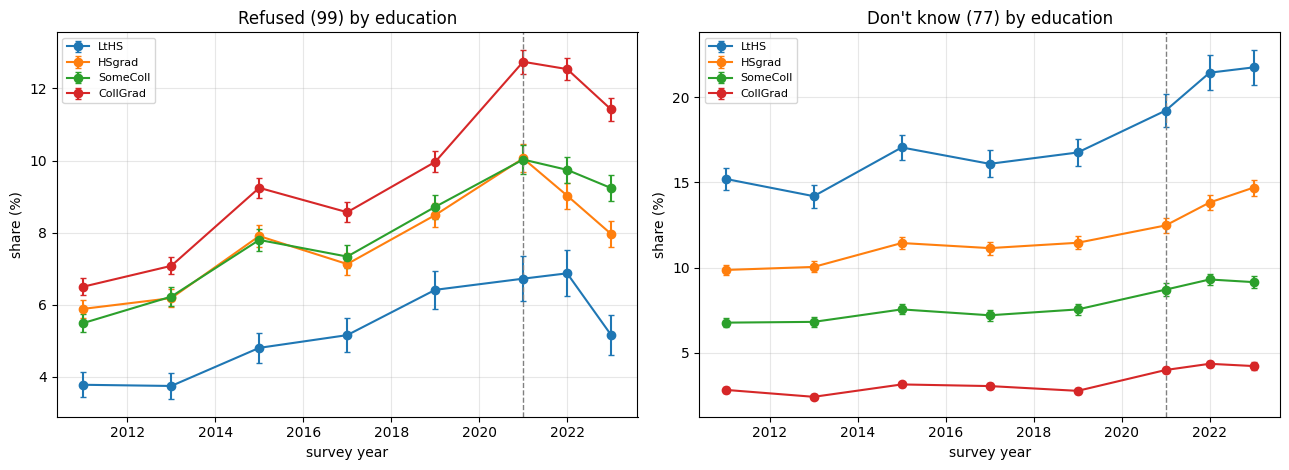

In [3]:
de = df[df['educ'].notna()].copy()
order = ['LtHS', 'HSgrad', 'SomeColl', 'CollGrad']
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
for flag, ax, ttl in [('refused', axes[0], 'Refused (99)'), ('dk', axes[1], "Don't know (77)")]:
    g = my.wprop(de, flag, by=['year', 'educ'])
    for e in order:
        s = g[g['educ'] == e].sort_values('year')
        ax.errorbar(s['year'], 100*s['p'], yerr=100*1.96*s['se'], marker='o',
                    capsize=2, label=e)
    ax.axvline(2021, color='gray', ls='--', lw=1)
    ax.set_xlabel('survey year'); ax.set_ylabel('share (%)'); ax.set_title(f'{ttl} by education')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Age, period, and cohort

Within any one year, age and birth cohort are the same axis. Plotting nonresponse by
**age group, one line per survey year**, separates the three: if the curves overlay,
it is an **age** effect stable across periods; if the whole family shifts up over
years, a **period** effect; if a fixed birth cohort (a diagonal across panels) carries
its level as it ages, a **cohort** effect. (Full APC effects are not separately
identified — this is the descriptive read.)

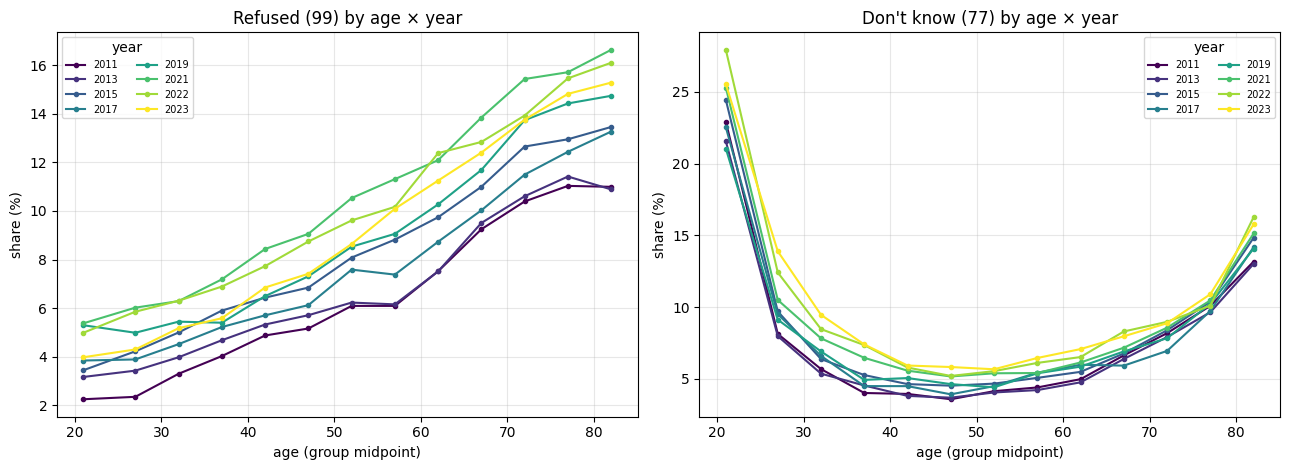

In [4]:
da = df[df['age_mid'].notna()].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
years = sorted(da['year'].unique())
cmap = plt.cm.viridis(np.linspace(0, 1, len(years)))
for flag, ax, ttl in [('refused', axes[0], 'Refused (99)'), ('dk', axes[1], "Don't know (77)")]:
    g = my.wprop(da, flag, by=['year', 'age_mid'])
    for yr, c in zip(years, cmap):
        s = g[g['year'] == yr].sort_values('age_mid')
        ax.plot(s['age_mid'], 100*s['p'], '-o', ms=3, color=c, label=str(yr))
    ax.set_xlabel('age (group midpoint)'); ax.set_ylabel('share (%)'); ax.set_title(f'{ttl} by age × year')
    ax.legend(fontsize=7, title='year', ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. By birth cohort directly

Pooling all years, nonresponse by **decade of birth**. Because each cohort is observed
at different ages across the 2011–2023 window, this mixes age and period — read it
together with the panel above.

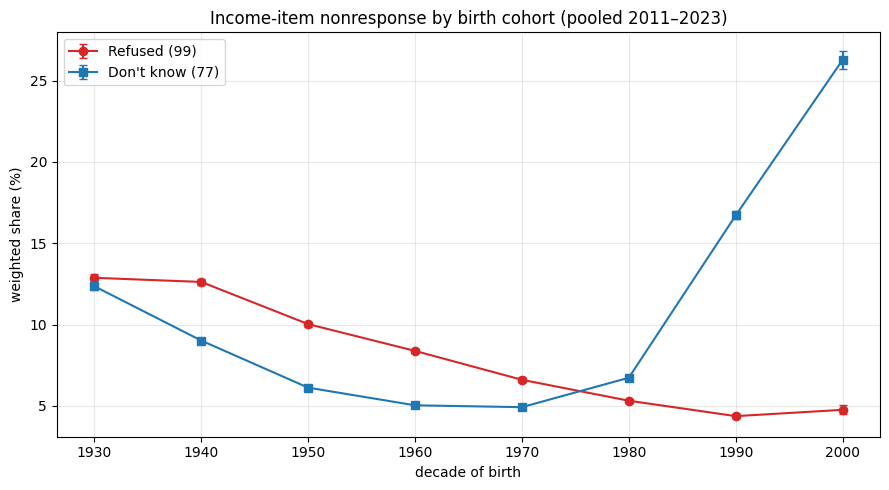

In [5]:
dc = df[df['cohort'].notna() & (df['cohort'] >= 1930) & (df['cohort'] <= 2000)].copy()
ref_c = my.wprop(dc, 'refused', by='cohort')
dk_c = my.wprop(dc, 'dk', by='cohort')
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(ref_c['cohort'], 100*ref_c['p'], yerr=100*1.96*ref_c['se'], marker='o',
            capsize=3, label='Refused (99)', color='C3')
ax.errorbar(dk_c['cohort'], 100*dk_c['p'], yerr=100*1.96*dk_c['se'], marker='s',
            capsize=3, label="Don't know (77)", color='C0')
ax.set_xlabel('decade of birth'); ax.set_ylabel('weighted share (%)')
ax.set_title('Income-item nonresponse by birth cohort (pooled 2011–2023)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

# save the tidy multi-year summary
out = []
for flag in ['refused', 'dk']:
    t = my.wprop(df, flag, by=['year']); t['flag'] = flag; out.append(t)
pd.concat(out).to_csv(os.path.join(DERIVED, 'brfss_income_nonresponse_by_year.csv'), index=False)

## 5. Does the education gradient itself differ by birth cohort?

Your original question, head-on: within each decade-of-birth band (pooled across
years), the education gradient in refusing vs saying don't know. Parallel lines mean
the education pattern is the same across cohorts; a fan means it differs.

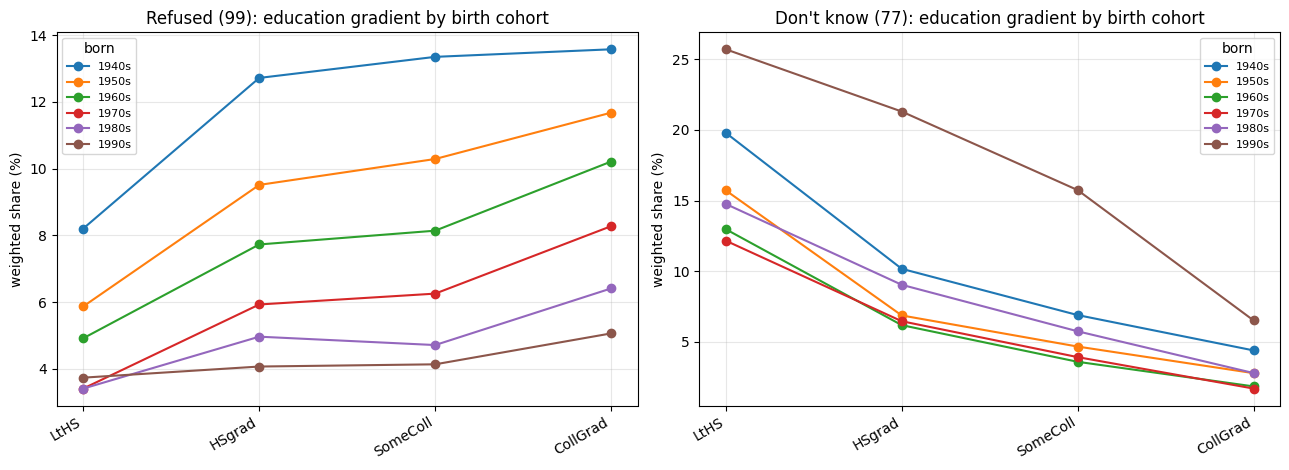

In [6]:
dec = df[df['educ'].notna() & df['cohort'].notna() & df['cohort'].between(1940, 1990)].copy()
cohs = sorted(dec['cohort'].unique())
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for flag, ax, ttl in [('refused', axes[0], 'Refused (99)'), ('dk', axes[1], "Don't know (77)")]:
    g = my.wprop(dec, flag, by=['cohort', 'educ'])
    for ch in cohs:
        s = g[g['cohort'] == ch].set_index('educ').reindex(order)
        ax.plot(range(len(order)), 100*s['p'], '-o', label=f"{int(ch)}s")
    ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=30, ha='right')
    ax.set_ylabel('weighted share (%)')
    ax.set_title(f'{ttl}: education gradient by birth cohort')
    ax.legend(fontsize=8, title='born'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## What the multi-year view shows

In [7]:
r0, r1 = ref_y.iloc[0], ref_y.iloc[-1]
d0, d1 = dk_y.iloc[0], dk_y.iloc[-1]
print(f"Refused:    {100*r0['p']:.1f}% in {int(r0['year'])}  ->  {100*r1['p']:.1f}% in {int(r1['year'])}")
print(f"Don't know: {100*d0['p']:.1f}% in {int(d0['year'])}  ->  {100*d1['p']:.1f}% in {int(d1['year'])}")
# education gradient in refusal, most recent year
g = my.wprop(de[de['year'] == de['year'].max()], 'refused', by='educ').set_index('educ')
print(f"\nRefusal by education in {int(de['year'].max())}:")
for e in order:
    if e in g.index:
        print(f"  {e:9s} {100*g.loc[e,'p']:.1f}%")

Refused:    5.8% in 2011  ->  9.3% in 2023
Don't know: 8.0% in 2011  ->  10.6% in 2023

Refusal by education in 2023:
  LtHS      5.2%
  HSgrad    8.0%
  SomeColl  9.2%
  CollGrad  11.4%


## Interpretation

**The two mechanisms are SES-patterned in *opposite* directions.** In 2023, refusing
the income question **rises** with education (5.2% among adults without a high-school
degree → 11.4% among college graduates), while saying **don't know falls** sharply
(21.7% → 4.2%). This is about as clean as evidence gets that refused and don't-know are
different phenomena: refusal looks like privacy / unwillingness, concentrated among
higher-SES respondents (the "high-income refuser" pattern), while don't-know looks like
genuine uncertainty, concentrated among lower-SES respondents. Collapsing them — as the
published derived income variables do — averages two opposite gradients into noise.

**It has not stayed the same over time.** From 2011 to 2023, weighted refusal rose
5.8% → 9.3% and don't-know 8.0% → 10.6% — income nonresponse is climbing. A
discontinuity coincides with the 2021 switch from `INCOME2` (8 brackets) to `INCOME3`
(11 brackets): refusal jumped to 11.5% in 2021 before easing to 9.9% by 2023, so part
of the trend is an instrument-change artifact, not pure respondent behavior — a caution
for anyone splicing income nonresponse across the 2020/2021 boundary.

**It differs by birth cohort.** Refusal declines almost monotonically across cohorts —
~13% among those born in the 1930s–40s down to ~4–5% among those born since 1980 —
while don't-know is U-shaped: lowest for mid-century cohorts and highest among the
youngest (26% among those born in the 2000s, observed as young adults who often don't
know household income). And the **education gradient in refusal itself shrinks across
cohorts**: the college-vs-no-HS refusal gap is +5–6 points for cohorts born in the
1940s–60s but only ~+1 point for those born in the 1990s. So "the educated refuse more"
is a feature of older cohorts that is fading in younger ones.

**Why it matters for the modeling.** This is exactly why model C (notebooks 03/05)
keeps the two codes separate and sweeps refusal MNAR in one direction: the data say
refusal carries a higher-SES (plausibly higher-income) signature while don't-know
carries a lower-SES one — opposite tilts that a single "missing" category would cancel.

_Caveats: with repeated cross-sections, age, period, and cohort are not separately
identified (older cohorts are observed at older ages, the youngest only as young
adults), so the cohort contrasts mix in age and period — read them alongside the
age × year panel. The 2021 instrument change is a period confound. All shares are
survey-weighted with a design-naive (effective-n) interval._